In [1]:
import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional, Dict, Any, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Config
# ----------------------------

@dataclass(frozen=True)
class PlotConfig:
    title: str = "ISMB26 Results"
    ns_filter: str = "molecular_function"  # or None for all
    functional_metric: str = "f_w"     # e.g., f_micro, f, s, ru, mi, etc.
    segment_metric: str = "segment_fragmentation_ratio_mean"  # from your segment CSV
    split_order: Tuple[str, ...] = ("train", "valid", "test")
    figsize: Tuple[float, float] = (14, 9)
    dpi: int = 150


# ----------------------------
# Helpers: parsing method/K/setting
# ----------------------------

_METHOD_K_RE = re.compile(r"""
    (?P<method>mincut|puffin)
    _K(?P<K>\d+)
    (?P<v2>_v2)?
""", re.VERBOSE)



_SETTING_RE = re.compile(r"/(?P<setting>\d{2,3})/evaluation_|/(?P<setting2>\d{2,3})/(train|valid|test)_summary\.json")


def add_method_key(df: pd.DataFrame, method_col="method", K_col="K", out_col="method_key") -> pd.DataFrame:
    df = df.copy()
    df[out_col] = df[method_col].astype(str) + "_K" + df[K_col].astype(int).astype(str)
    return df

def strict_drop_v2_anywhere(df: pd.DataFrame, cols=("file", "method", "method_label", "method_key")) -> pd.DataFrame:
    """Drop rows if ANY of the listed columns contains v2 markers."""
    pat = re.compile(r"(^|[_\-/])v2($|[_\-/])|_v2\b|\bv2\b", re.IGNORECASE)
    keep = pd.Series(True, index=df.index)
    for c in cols:
        if c in df.columns:
            keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
    return df.loc[keep].copy()


def drop_v2(df, method_col="method"):
    """Remove any rows that correspond to v2 variants."""
    pat = re.compile(r"\bv2\b|_v2\b|-v2\b", re.IGNORECASE)
    mask = ~df[method_col].astype(str).str.contains(pat, regex=True)
    return df.loc[mask].copy()

# Example: whitelist only stable variants
ALLOWED_METHOD_PATTERNS = [
    r"^puffin_K(16|32|64|128)$",
    r"^mincut_K(16|32|64)$",
    
]

def filter_methods_regex(df, patterns=ALLOWED_METHOD_PATTERNS, method_col="method"):
    combined = "(" + ")|(".join(patterns) + ")"
    return df[df[method_col].astype(str).str.contains(combined, regex=True)].copy()



def _parse_method_k_from_path(path_str: str) -> Tuple[Optional[str], Optional[int], bool]:
    m = _METHOD_K_RE.search(path_str)
    if not m:
        return None, None, False
    method = m.group("method")
    K = int(m.group("K"))
    is_v2 = m.group("v2") is not None
    # For naming clarity, fold v2 into method label
    method_label = f"{method}_v2" if is_v2 else method
    return method_label, K, is_v2

def _parse_setting_from_path(path_str: str) -> Optional[int]:
    m = _SETTING_RE.search(path_str)
    if not m:
        return None
    s = m.group("setting") or m.group("setting2")
    return int(s) if s else None


# ----------------------------
# Loaders
# ----------------------------

def read_functional_tsv(path: str | Path) -> pd.DataFrame:
    """
    Reads the big functional TSV (one row per evaluation artifact).
    Adds parsed columns: method, K, setting.
    """
    path = Path(path)
    df = pd.read_csv(path, sep="\t")

    # normalize column names if needed
    df.columns = [c.strip() for c in df.columns]

    if "file" not in df.columns:
        raise ValueError("Functional TSV must contain a 'file' column with run path info.")

    # parse metadata
    parsed = df["file"].astype(str).apply(_parse_method_k_from_path)
    df["method"] = parsed.apply(lambda x: x[0])
    df["K"] = parsed.apply(lambda x: x[1])
    df["is_v2"] = parsed.apply(lambda x: x[2])

    df["setting"] = df["file"].astype(str).apply(_parse_setting_from_path)

    # Keep only rows we can interpret
    df = df[df["method"].notna() & df["K"].notna() & df["setting"].notna()].copy()

    return df


def read_segment_key_metrics_csv(path: str | Path) -> pd.DataFrame:
    """
    Reads the segment summary CSV (your 'segment key metrics file').
    Adds a stable method label (e.g. puffin, puffin_K32_v2 -> puffin_v2)
    and coerces numeric columns.
    """
    path = Path(path)
    seg = pd.read_csv(path)

    seg.columns = [c.strip() for c in seg.columns]

    required = {"file", "method", "split"}
    missing = required - set(seg.columns)
    if missing:
        raise ValueError(f"Segment CSV missing columns: {missing}")

    # If K exists but is blank for puffin_K128_v2 in your paste, keep as numeric where possible
    if "K" in seg.columns:
        seg["K"] = pd.to_numeric(seg["K"], errors="coerce")

    # Derive method label w/ v2 where possible from file path or method column
    # method column contains e.g. "puffin_K128_v2" in your paste sometimes; normalize:
    def norm_method(m: str, file_path: str) -> str:
        m = str(m)
        file_path = str(file_path)
        # If method already says v2, keep it
        if "v2" in m:
            # try to reduce puffin_K32_v2 -> puffin_v2 for grouping, but keep K separately
            if m.startswith("puffin") and "v2" in m:
                return "puffin_v2"
            if m.startswith("mincut") and "v2" in m:
                return "mincut_v2"
        # else parse from file path
        pm, _, _ = _parse_method_k_from_path(file_path)
        if pm is not None:
            return pm  # puffin or puffin_v2 etc.
        # fallback: strip K suffix if present
        return m.split("_K")[0]

    seg["method_label"] = [
        norm_method(m, f) for m, f in zip(seg["method"], seg["file"])
    ]

    return seg


def read_segment_summary_jsons(json_paths: Iterable[str | Path]) -> pd.DataFrame:
    """
    Optional: load many *_summary.json files (train/valid/test).
    Returns a flat table of key means, matching your CSV schema where possible.
    """
    rows: List[Dict[str, Any]] = []
    for p in json_paths:
        p = Path(p)
        with p.open("r") as f:
            obj = json.load(f)

        file_str = str(p)
        method_label, K, _ = _parse_method_k_from_path(file_str)
        split = "train" if "/train/" in file_str else ("valid" if "/valid/" in file_str else ("test" if "/test/" in file_str else None))
        setting = _parse_setting_from_path(file_str)

        # Pull a compact subset (extend as you like)
        protein = obj.get("protein_level", {})
        segment = obj.get("segment_level", {})
        def mean(dct, key):
            return (dct.get(key, {}) or {}).get("mean", np.nan)

        rows.append({
            "file": file_str,
            "method_label": method_label,
            "K": K,
            "split": split,
            "setting": setting,
            "n_proteins": obj.get("n_proteins", np.nan),
            "n_segments": obj.get("n_segments", np.nan),

            "protein_usage_gini_mean": mean(protein, "usage_gini"),
            "protein_usage_entropy_norm_mean": mean(protein, "usage_entropy_norm"),
            "protein_unique_labels_mean": mean(protein, "unique_labels"),
            "protein_boundaries_mean": mean(protein, "boundaries"),

            "segment_n_res_mean": mean(segment, "n_res"),
            "segment_seq_span_mean": mean(segment, "seq_span"),
            "segment_seq_compactness_mean": mean(segment, "seq_compactness"),
            "segment_fragmentation_ratio_mean": mean(segment, "fragmentation_ratio"),
            "segment_mean_intra_ca_dist_mean": mean(segment, "mean_intra_ca_dist"),
            "segment_contact_density_mean": mean(segment, "contact_density"),
            "segment_cut_ratio_mean": mean(segment, "cut_ratio"),
            "segment_rg_mean": mean(segment, "rg"),
            "segment_packing_density_mean": mean(segment, "packing_density"),
            "segment_log_packing_density_mean": mean(segment, "log_packing_density"),
        })

    df = pd.DataFrame(rows)
    df = df[df["method_label"].notna() & df["K"].notna() & df["split"].notna()].copy()
    return df


# ----------------------------
# Selection logic (no pivot tables)
# ----------------------------

def filter_functional(
    df: pd.DataFrame,
    ns: Optional[str] = "molecular_function",
    eval_kind_preference: Tuple[str, ...] = ("evaluation_best_f_micro", "evaluation_best_f", "evaluation_best_s"),
) -> pd.DataFrame:
    """
    Your TSV contains multiple 'evaluation_best_*.tsv' artifacts per run.
    This keeps one row per (method,K,setting) based on preference order.
    """
    if ns is not None and "ns" in df.columns:
        df = df[df["ns"] == ns].copy()

    # Determine eval kind from file name
    # e.g., ".../evaluation_best_f_micro.tsv" -> "evaluation_best_f_micro"
    df["eval_kind"] = df["file"].astype(str).str.extract(r"(evaluation_best_[^/]+)\.tsv", expand=False)

    # rank kinds by preference
    pref_rank = {k: i for i, k in enumerate(eval_kind_preference)}
    df["kind_rank"] = df["eval_kind"].map(pref_rank).fillna(9999).astype(int)

    # keep best-ranked row per run key
    key = ["method", "K", "setting"]
    df = (
        df.sort_values(key + ["kind_rank"])
          .groupby(key, as_index=False)
          .head(1)
          .drop(columns=["kind_rank"])
    )
    return df


# ----------------------------
# Plotting: multi-panel figure
# ----------------------------

def _sorted_unique(vals: Iterable) -> List:
    vals = [v for v in vals if pd.notna(v)]
    return sorted(set(vals))


In [2]:
def prepare_functional_df(functional_path: str | Path, cfg: PlotConfig) -> pd.DataFrame:
    func = read_functional_tsv(functional_path)

    # keep only interpretable + filter ns + select eval_kind
    func = filter_functional(func, ns=cfg.ns_filter)

    # drop v2 *hard*
    func = strict_drop_v2_anywhere(func, cols=("file", "method"))
    func = func[func["is_v2"] == False].copy()

    # create canonical key
    func = add_method_key(func, method_col="method", K_col="K", out_col="method_key")

    # optional: whitelist allowed Ks / methods (now it will work!)
    func = filter_methods_regex(func, patterns=ALLOWED_METHOD_PATTERNS, method_col="method_key")

    # keep only columns you actually need for plotting
    keep = ["method_key", "method", "K", "setting", cfg.functional_metric]
    keep = [c for c in keep if c in func.columns]
    func = func[keep].copy()

    # rename for uniformity
    func = func.rename(columns={"setting": "threshold"})
    return func

def prepare_segmentation_df_from_csv(seg_csv_path: str | Path) -> pd.DataFrame:
    seg = read_segment_key_metrics_csv(seg_csv_path)

    # First, parse method/K from file path reliably (stronger than seg["method"])
    parsed = seg["file"].astype(str).apply(_parse_method_k_from_path)
    seg["parsed_method"] = parsed.apply(lambda x: x[0])   # puffin / puffin_v2 / mincut...
    seg["parsed_K"] = parsed.apply(lambda x: x[1])
    seg["parsed_is_v2"] = parsed.apply(lambda x: x[2])

    # fill K from parsed when missing
    if "K" not in seg.columns:
        seg["K"] = seg["parsed_K"]
    else:
        seg["K"] = seg["K"].fillna(seg["parsed_K"])

    # base method should be "puffin" or "mincut" only (strip v2)
    seg["method"] = seg["parsed_method"].astype(str).str.replace("_v2", "", regex=False)

    # setting (threshold) from path if exists
    if "setting" not in seg.columns:
        seg["setting"] = seg["file"].astype(str).apply(_parse_setting_from_path)

    # HARD drop v2
    seg = seg[seg["parsed_is_v2"] == False].copy()
    seg = strict_drop_v2_anywhere(seg, cols=("file", "method", "method_label"))

    # canonical key
    seg = add_method_key(seg, method_col="method", K_col="K", out_col="method_key")

    # keep test split only for main figure
    seg = seg[seg["split"] == "test"].copy()

    # rename for merge
    seg = seg.rename(columns={"setting": "threshold"})

    return seg

def prepare_segmentation_df_from_jsons(json_root: str | Path) -> pd.DataFrame:
    json_paths = list(Path(json_root).rglob("*_summary.json"))
    seg = read_segment_summary_jsons(json_paths)

    # method_label is puffin / puffin_v2 etc.
    seg["method"] = seg["method_label"].astype(str).str.replace("_v2", "", regex=False)

    # HARD drop v2
    seg = strict_drop_v2_anywhere(seg, cols=("file", "method_label", "method"))
    seg = seg[seg["method_label"].astype(str).str.contains("v2", case=False, regex=False) == False].copy()

    # canonical key
    seg = add_method_key(seg, method_col="method", K_col="K", out_col="method_key")

    # keep test split for main figure
    seg = seg[seg["split"] == "test"].copy()

    # rename for merge
    seg = seg.rename(columns={"setting": "threshold"})

    return seg




In [3]:
def build_main_figure_df(
    cfg: PlotConfig,
    functional_tsv_path: str | Path,
    seg_csv_path: Optional[str | Path] = None,
    seg_json_root: Optional[str | Path] = None,
) -> pd.DataFrame:

    func = prepare_functional_df(functional_tsv_path, cfg)

    if seg_csv_path is not None:
        seg = prepare_segmentation_df_from_csv(seg_csv_path)
    elif seg_json_root is not None:
        seg = prepare_segmentation_df_from_jsons(seg_json_root)
    else:
        raise ValueError("Provide either seg_csv_path or seg_json_root.")

    # Decide merge keys: if seg has threshold, use it; else merge method_key only
    merge_keys = ["method_key"]
    if "threshold" in seg.columns and "threshold" in func.columns:
        # threshold may be missing in seg CSV; only include if not all NaN
        if seg["threshold"].notna().any():
            merge_keys = ["method_key", "threshold"]

    # reduce seg columns (keep only the metrics you plot + metadata)
    seg_keep = ["method_key", "K", "threshold", "split"]
    seg_keep += [c for c in seg.columns if c.endswith("_mean")]  # your metric convention
    seg_keep = [c for c in seg_keep if c in seg.columns]
    seg_small = seg[seg_keep].copy()

    df = func.merge(seg_small, on=merge_keys, how="left", suffixes=("", "_seg"))

    # final hard guarantee
    df = strict_drop_v2_anywhere(df, cols=("method_key", "method"))
    df = filter_methods_regex(df, patterns=ALLOWED_METHOD_PATTERNS, method_col="method_key")

    return df


In [4]:
def build_main_figure_df(
    cfg: PlotConfig,
    functional_tsv_path: str | Path,
    seg_csv_path: Optional[str | Path] = None,
    seg_json_root: Optional[str | Path] = None,
    keep_seg_only: bool = True,   # <--- new: keep seg rows even if func missing
) -> pd.DataFrame:
    """
    Returns a table that contains:
      - functional metrics when available
      - segmentation metrics always (if present in seg sources)
    If keep_seg_only=True, segmentation-only runs are preserved (functional metric will be NaN).
    """

    func = prepare_functional_df(functional_tsv_path, cfg)

    if seg_csv_path is not None:
        seg = prepare_segmentation_df_from_csv(seg_csv_path)
    elif seg_json_root is not None:
        seg = prepare_segmentation_df_from_jsons(seg_json_root)
    else:
        raise ValueError("Provide either seg_csv_path or seg_json_root.")

    # Decide merge keys
    merge_keys = ["method_key"]
    if "threshold" in seg.columns and "threshold" in func.columns:
        # Only merge on threshold if seg actually has usable thresholds
        if seg["threshold"].notna().any():
            merge_keys = ["method_key", "threshold"]

    # Reduce seg columns (keep only metadata + metrics)
    seg_keep = ["method_key", "K", "threshold", "split"]
    seg_keep += [c for c in seg.columns if c.endswith("_mean")]
    seg_keep = [c for c in seg_keep if c in seg.columns]
    seg_small = seg[seg_keep].copy()

    # Reduce func columns (keep only what you need)
    func_keep = ["method_key", "method", "K", "threshold", cfg.functional_metric]
    func_keep = [c for c in func_keep if c in func.columns]
    func_small = func[func_keep].copy()

    # --- merge ---
    # If we want seg-only rows, anchor on seg (left) or do outer merge.
    if keep_seg_only:
        df = seg_small.merge(func_small, on=merge_keys, how="left", suffixes=("", "_func"))
    else:
        df = func_small.merge(seg_small, on=merge_keys, how="left", suffixes=("", "_seg"))

    # Fill method if missing (happens for seg-only rows)
    if "method" not in df.columns or df["method"].isna().any():
        # derive base method from method_key: "puffin_K64" -> "puffin"
        if "method" not in df.columns:
            df["method"] = np.nan
        df.loc[df["method"].isna(), "method"] = (
            df.loc[df["method"].isna(), "method_key"].astype(str).str.split("_K").str[0]
        )

    # Keep a single K column (prefer seg K, else func K)
    if "K_x" in df.columns and "K_y" in df.columns:
        df["K"] = df["K_x"].combine_first(df["K_y"])
        df = df.drop(columns=["K_x", "K_y"])
    elif "K" not in df.columns:
        # try to parse from method_key if needed
        df["K"] = pd.to_numeric(df["method_key"].astype(str).str.extract(r"_K(\d+)", expand=False), errors="coerce")

    # Final hard guarantee: drop v2 anywhere + whitelist stable variants
    df = strict_drop_v2_anywhere(df, cols=("method_key", "method"))
    df = filter_methods_regex(df, patterns=ALLOWED_METHOD_PATTERNS, method_col="method_key")

    # Optional: make sure split is present (if you later facet by split)
    if "split" in df.columns and df["split"].notna().any():
        df["split"] = pd.Categorical(df["split"], categories=list(cfg.split_order), ordered=True)

    return df


In [5]:
import matplotlib.pyplot as plt

def panel_A_function(df, x="threshold", y="f_w", hue="K", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6,4))

    # aggregate
    g = (df.groupby([hue, x])[y]
           .mean()
           .reset_index()
           .sort_values([hue, x]))

    for m, sub in g.groupby(hue):
        ax.plot(sub[x], sub[y], marker="o", label=m)

    ax.set_xlabel("Split threshold")
    ax.set_ylabel(y.upper())
    ax.set_title("A. Function prediction vs threshold")
    ax.legend(frameon=False, fontsize=8)
    return ax


In [6]:
def panel_B_protein_degeneracy(df, metrics, x="method_key", ax=None):
    # metrics: list like ["n_boundaries_mean", "mean_run_length", "label_entropy"]
    if ax is None:
        _, ax = plt.subplots(figsize=(7,4))

    # simple: make a grouped bar by melting
    import pandas as pd
    d = df.groupby(x)[metrics].mean().reset_index()
    m = d.melt(id_vars=[x], value_vars=metrics, var_name="metric", value_name="value")

    # manual grouped bars
    methods = list(d[x])
    metric_names = metrics
    width = 0.8 / len(metric_names)

    for j, metric in enumerate(metric_names):
        vals = m[m["metric"] == metric].set_index(x).loc[methods]["value"].values
        ax.bar([i + j*width for i in range(len(methods))], vals, width=width, label=metric)

    ax.set_xticks([i + width*(len(metric_names)-1)/2 for i in range(len(methods))])
    ax.set_xticklabels(methods, rotation=25, ha="right")
    ax.set_title("B. Protein-level degeneracy diagnostics")
    ax.legend(frameon=False, fontsize=8)
    return ax


In [7]:
def panel_C_segment_degeneracy(df, metrics, x="method_key", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7,4))
    # identical to panel_B_protein_degeneracy but with different title
    ax = panel_B_protein_degeneracy(df, metrics=metrics, x=x, ax=ax)
    ax.set_title("C. Segment-level degeneracy diagnostics")
    return ax


In [8]:
def panel_D_structure(df, metrics, x="method_key", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7,4))
    ax = panel_B_protein_degeneracy(df, metrics=metrics, x=x, ax=ax)
    ax.set_title("D. Structure coherence (where available)")
    return ax


In [9]:
def plot_metric_vs_K(ax, df, metric, title, ylabel, methods=("mincut","puffin"), split="test"):
    tmp = df.copy()
    if "split" in tmp.columns and split is not None:
        tmp = tmp[tmp["split"] == split].copy()

    # average over settings (or thresholds) if present
    group_cols = ["method", "K"]
    if "method_label" in tmp.columns and "method" not in tmp.columns:
        # if your merged df uses method_label, normalize
        tmp["method"] = tmp["method_label"]

    agg = (tmp[tmp["method"].isin(methods)]
           .groupby(group_cols, as_index=False)[metric]
           .mean())

    for m in methods:
        sub = agg[agg["method"] == m].sort_values("K")
        if len(sub) == 0:
            continue
        ax.plot(sub["K"], sub[metric], marker="o", label=m)

    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    return ax

In [10]:

df = build_main_figure_df(
    cfg=PlotConfig(),
    functional_tsv_path="../ismb26/models/puffin_best_table.tsv",
    seg_csv_path="../ismb26/results/segment_summary_key_metrics.csv",
    # seg_json_root="data/ismb26_segment_jsons/",  # alternatively
)
df.head()



/tmp/ipykernel_3109141/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_3109141/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_3109141/1427850406.py:72: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[method_col].astype(str).str.contains(combined, regex=True)].copy()
/tmp/ipykernel_3109141/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_

,method_key,K,threshold,split,protein_n_res_mean,protein_unique_labels_mean,protein_boundaries_mean,protein_mean_run_length_mean,protein_usage_gini_mean,protein_usage_entropy_norm_mean,...,delta_mean_intra_ca_dist_mean,delta_contact_density_mean,delta_cut_ratio_mean,delta_rg_mean,delta_packing_density_mean,delta_log_packing_density_mean,method,K_func,threshold_func,f_w
0,mincut_K16,16.0,None,test,303.778289,14.472248,65.496473,4.921375,0.167921,0.976107,...,-13.255304,0.451581,-0.316696,-9.147632,0.035108,2.202078,mincut,NaN,NaN,NaN
1,mincut_K32,32.0,None,test,303.778289,23.196872,66.487274,4.964203,0.163866,0.981607,...,-18.568977,0.620908,-0.287075,-13.215548,0.052707,3.268200,mincut,NaN,NaN,NaN
2,mincut_K64,64.0,None,test,303.778289,12.580803,49.372892,7.293289,0.217482,0.951417,...,-31.601839,0.401585,-0.392706,-25.804390,0.041281,3.382197,mincut,NaN,NaN,NaN
3,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,30.0,0.689
4,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,40.0,0.691


In [11]:
df.columns

Index(['method_key', 'K', 'threshold', 'split', 'protein_n_res_mean',
       'protein_unique_labels_mean', 'protein_boundaries_mean',
       'protein_mean_run_length_mean', 'protein_usage_gini_mean',
       'protein_usage_entropy_norm_mean', 'segment_n_res_mean',
       'segment_seq_span_mean', 'segment_seq_compactness_mean',
       'segment_run_count_mean', 'segment_max_run_length_mean',
       'segment_fragmentation_ratio_mean', 'segment_mean_intra_ca_dist_mean',
       'segment_contact_density_mean', 'segment_cut_ratio_mean',
       'segment_rg_mean', 'segment_packing_density_mean',
       'segment_log_packing_density_mean', 'delta_seq_span_mean',
       'delta_seq_compactness_mean', 'delta_run_count_mean',
       'delta_max_run_length_mean', 'delta_fragmentation_ratio_mean',
       'delta_mean_intra_ca_dist_mean', 'delta_contact_density_mean',
       'delta_cut_ratio_mean', 'delta_rg_mean', 'delta_packing_density_mean',
       'delta_log_packing_density_mean', 'method', 'K_func', '

In [12]:
df

,method_key,K,threshold,split,protein_n_res_mean,protein_unique_labels_mean,protein_boundaries_mean,protein_mean_run_length_mean,protein_usage_gini_mean,protein_usage_entropy_norm_mean,...,delta_mean_intra_ca_dist_mean,delta_contact_density_mean,delta_cut_ratio_mean,delta_rg_mean,delta_packing_density_mean,delta_log_packing_density_mean,method,K_func,threshold_func,f_w
0,mincut_K16,16.0,None,test,303.778289,14.472248,65.496473,4.921375,0.167921,0.976107,...,-13.255304,0.451581,-0.316696,-9.147632,0.035108,2.202078,mincut,NaN,NaN,NaN
1,mincut_K32,32.0,None,test,303.778289,23.196872,66.487274,4.964203,0.163866,0.981607,...,-18.568977,0.620908,-0.287075,-13.215548,0.052707,3.268200,mincut,NaN,NaN,NaN
2,mincut_K64,64.0,None,test,303.778289,12.580803,49.372892,7.293289,0.217482,0.951417,...,-31.601839,0.401585,-0.392706,-25.804390,0.041281,3.382197,mincut,NaN,NaN,NaN
3,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,30.0,0.689
4,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,40.0,0.691
5,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,50.0,0.706
6,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,70.0,0.724
7,puffin_K16,16.0,None,test,303.778289,14.426863,64.087703,5.100227,0.153242,0.980852,...,-13.317400,0.453159,-0.318846,-9.225993,0.035033,2.221261,puffin,16.0,95.0,0.742
8,puffin_K32,32.0,None,test,303.778289,23.139834,66.772769,5.014474,0.163788,0.981514,...,-32.126138,0.600841,-0.291458,-24.047371,0.056995,3.915633,puffin,32.0,30.0,0.669
9,puffin_K32,32.0,None,test,303.778289,23.139834,66.772769,5.014474,0.163788,0.981514,...,-32.126138,0.600841,-0.291458,-24.047371,0.056995,3.915633,puffin,32.0,40.0,0.677


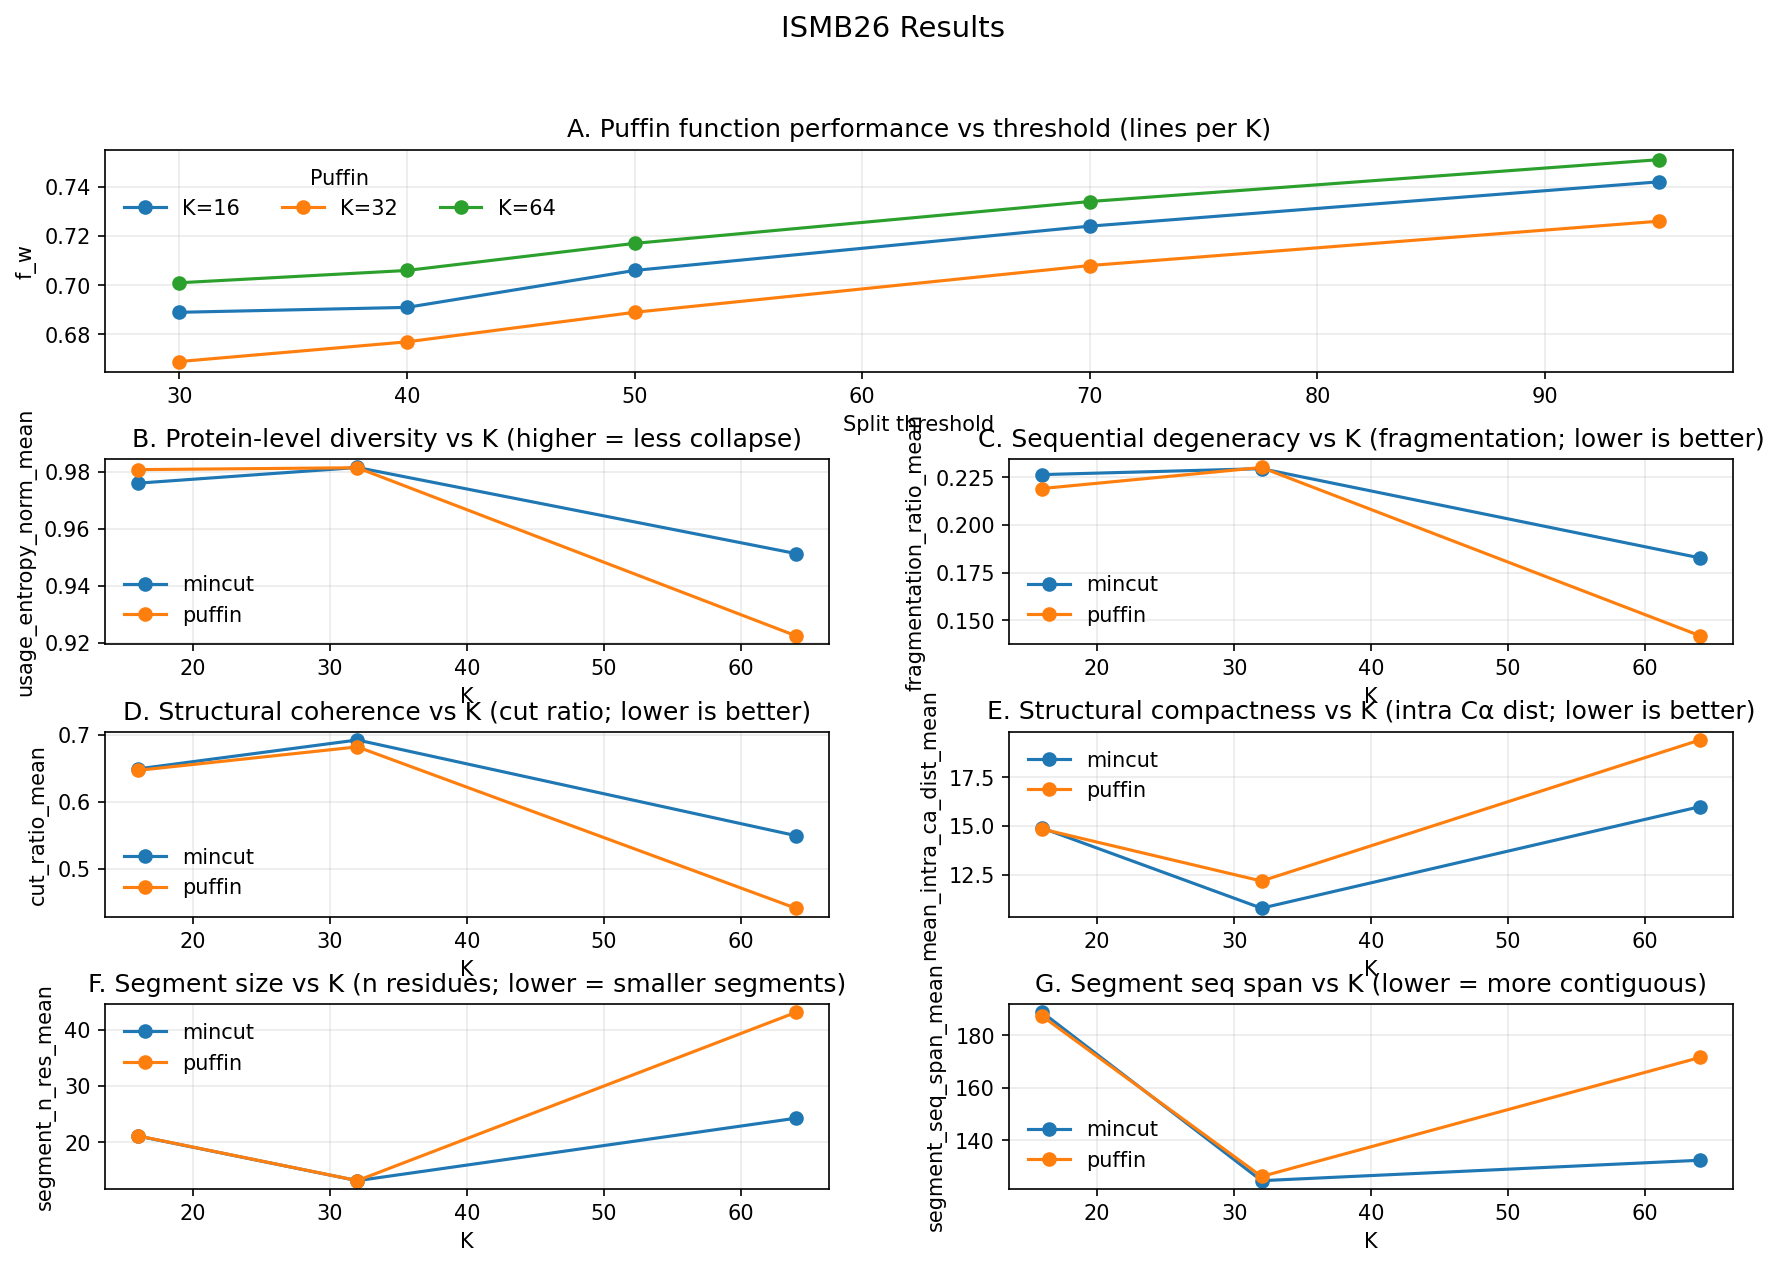

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _ensure_method_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "method" not in df.columns:
        df["method"] = df["method_key"].astype(str).str.split("_K").str[0]
    if "K" not in df.columns or df["K"].isna().all():
        df["K"] = pd.to_numeric(df["method_key"].astype(str).str.extract(r"_K(\d+)", expand=False), errors="coerce")
    return df

def _order_K(df: pd.DataFrame, K_col="K"):
    Ks = sorted([int(k) for k in df[K_col].dropna().unique()])
    return Ks

def _lineplot_by_K(ax, dsub, xcol, ycol, label_prefix="", linestyle="-"):
    # one line per K
    for K in _order_K(dsub):
        dk = dsub[dsub["K"] == K].sort_values(xcol)
        if dk.empty:
            continue
        ax.plot(dk[xcol], dk[ycol], marker="o", linestyle=linestyle, label=f"{label_prefix}K={K}")

def _metric_lines_vs_K(ax, df, metric, title, ylabel=None):
    """
    Compare mincut vs puffin across K for ONE metric.
    """
    d = df.dropna(subset=["K"]).copy()
    if metric not in d.columns:
        ax.text(0.5, 0.5, f"Missing column: {metric}", ha="center", va="center")
        ax.set_axis_off()
        return

    # average over split/threshold if present (you can change agg to median)
    gcols = ["method", "K"]
    d_agg = d.groupby(gcols, as_index=False)[metric].mean()

    # plot each method as a line
    for method in ["mincut", "puffin"]:
        dm = d_agg[d_agg["method"] == method].sort_values("K")
        if dm.empty:
            continue
        ax.plot(dm["K"], dm[metric], marker="o", label=method)

    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

def main_figure(df: pd.DataFrame, cfg: PlotConfig, split_for_function="test"):
    """
    Better comparison figure:
      A) Puffin function vs threshold (lines per K)
      B) Sequential diagnostics vs K (mincut vs puffin)
      C) Sequential diagnostics vs K (another metric set)
      D) Structural coherence vs K (mincut vs puffin)
    """
    df = _ensure_method_cols(df)

    # ---------------------------
    # Choose metric groups
    # ---------------------------
    # "Sequential" (purely sequence-layout style degeneracy)
    seq_metrics = [
        ("segment_fragmentation_ratio_mean", "Seq degeneracy: fragmentation (↓ better)"),
        ("segment_run_count_mean", "Seq degeneracy: run count (↓ better)"),
        ("segment_seq_compactness_mean", "Seq degeneracy: seq compactness (↑ better)"),
    ]

    # "Protein-level" degeneracy (usage collapsing etc.)
    prot_metrics = [
        ("protein_boundaries_mean", "Protein degeneracy: boundaries (↓ better)"),
        ("protein_mean_run_length_mean", "Protein degeneracy: mean run length (↑ often degeneracy)"),
        ("protein_usage_entropy_norm_mean", "Protein degeneracy: usage entropy norm (↑ more diverse)"),
    ]

    # "Structural" coherence metrics
    struct_metrics = [
        ("segment_cut_ratio_mean", "Structural coherence: cut ratio (↓ better)"),
        ("segment_mean_intra_ca_dist_mean", "Structural coherence: intra Cα dist (↓ better)"),
    ]

    func_metric = cfg.functional_metric  # e.g. "f_micro" or "f_w"
    threshold_col = "threshold_func"
    # ---------------------------
    # Prepare function subset (PUFFIN only)
    # ---------------------------
    dfunc = df.copy()
    # If you have 'split' column, pick one
    if "split" in dfunc.columns:
        dfunc = dfunc[dfunc["split"] == split_for_function].copy()

    dfunc = dfunc[(dfunc["method"] == "puffin") & dfunc[func_metric].notna()].copy()
    # If threshold missing, warn instead of drawing empty
    has_func = (not dfunc.empty) and (threshold_col in dfunc.columns) and dfunc[threshold_col].notna().any()

    # ---------------------------
    # Build the figure (sequential + structural)
    # ---------------------------
    fig = plt.figure(figsize=cfg.figsize, dpi=cfg.dpi)
    gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1, 1], hspace=0.45, wspace=0.25)

    # A) Puffin function vs threshold
    # axA = fig.add_subplot(gs[0, :])
    # axA.set_title("A. Puffin function performance vs threshold (lines per K)")
    # if has_func:
    #     # aggregate over duplicates
    #     dA = dfunc.groupby(["K", threshold_col], as_index=False)[func_metric].mean()
    #     _lineplot_by_K(axA, dA, xcol=threshold_col, ycol=func_metric, label_prefix="")
    #     axA.set_xlabel("Split threshold" if threshold_col == "threshold_func" else threshold_col)
    #     axA.set_ylabel(func_metric)
    #     axA.grid(True, alpha=0.25)
    #     axA.legend(title="Puffin", frameon=False, ncol=4)
    # else:
    #     axA.text(
    #         0.5, 0.5,
    #         f"No function data to plot.\nNeed non-NaN '{func_metric}' for puffin (split={split_for_function}).",
    #         ha="center", va="center"
    #     )
    #     axA.set_axis_off()
 
    # B) Protein-level degeneracy vs K (pick the most informative 1 metric)
    axB = fig.add_subplot(gs[1, 0])
    _metric_lines_vs_K(
        axB, df,
        metric="protein_usage_entropy_norm_mean",
        title="B. Protein-level diversity vs K (higher = less collapse)",
        ylabel="usage_entropy_norm_mean"
    )

    # C) Sequential segmentation degeneracy vs K
    axC = fig.add_subplot(gs[1, 1])
    _metric_lines_vs_K(
        axC, df,
        metric="segment_fragmentation_ratio_mean",
        title="C. Sequential degeneracy vs K (fragmentation; lower is better)",
        ylabel="fragmentation_ratio_mean"
    )

    # D) Structural coherence vs K
    axD = fig.add_subplot(gs[2, 0])
    _metric_lines_vs_K(
        axD, df,
        metric="segment_cut_ratio_mean",
        title="D. Structural coherence vs K (cut ratio; lower is better)",
        ylabel="cut_ratio_mean"
    )

    # E) Another structural metric vs K (or swap with run_count/compactness)
    axE = fig.add_subplot(gs[2, 1])
    _metric_lines_vs_K(
        axE, df,
        metric="segment_mean_intra_ca_dist_mean",
        title="E. Structural compactness vs K (intra Cα dist; lower is better)",
        ylabel="mean_intra_ca_dist_mean"
    )

    axF = fig.add_subplot(gs[3, 0])  # NEW: segment size
    plot_metric_vs_K(
        axF, df,
        metric="segment_n_res_mean",
        title="F. Segment size vs K (n residues; lower = smaller segments)",
        ylabel="segment_n_res_mean",
    )

    axG = fig.add_subplot(gs[3, 1])  # optional: seq span


    # Optional second length plot
    plot_metric_vs_K(
        axG, df,
        metric="segment_seq_span_mean",
        title="G. Segment seq span vs K (lower = more contiguous)",
        ylabel="segment_seq_span_mean",
    )


    fig.suptitle(cfg.title, y=0.98, fontsize=14)

main_figure(df, cfg=PlotConfig(), split_for_function="test")


## Panel A — Puffin function performance vs threshold

**What it shows**

* Puffin’s **functional performance (F_w)** improves **monotonically** as the threshold increases.
* **K=64 > K=16 > K=32** across *all* thresholds.

**Interpretation**

* Larger K gives the model **more expressive segmentation capacity**, which translates into better downstream function prediction.
* Performance is **stable** across thresholds: no sharp drops → indicates **robust predictions**, not overfitting to a specific cutoff.

**Takeaway**

> *Puffin benefits from larger unit inventories, with K=64 consistently yielding the strongest functional performance.*

---

## Panel B — Protein-level diversity vs K (higher = less collapse)

Metric: **protein_usage_entropy_norm_mean**

**What it shows**

* Both methods behave similarly at **K=16–32**.
* At **K=64**, Puffin’s entropy drops more sharply than mincut’s.

**Interpretation**

* Higher entropy = residues spread across multiple units.
* Puffin slightly **focuses usage into fewer dominant units** at high K compared to mincut.
* Importantly: entropy is still **very high (>0.92)** → **no catastrophic collapse**.

**Takeaway**

> *At higher K, Puffin becomes more selective in unit usage, but remains far from degenerate.*

---

## Panel C — Sequential degeneracy vs K (fragmentation; lower is better)

Metric: **segment_fragmentation_ratio_mean**

**What it shows**

* Puffin’s fragmentation decreases **much faster** than mincut’s as K increases.
* At **K=64**, Puffin achieves **significantly lower fragmentation**.

**Interpretation**

* Puffin learns **more contiguous, cleaner segments**.
* Mincut maintains higher fragmentation even with more clusters.

**Takeaway**

> *Puffin produces structurally cleaner and less fragmented sequential segments than mincut, especially at larger K.*

---

## Panel D — Structural coherence vs K (cut ratio; lower is better)

Metric: **segment_cut_ratio_mean**

**What it shows**

* Puffin and mincut are similar at lower K.
* At **K=64**, Puffin has a **markedly lower cut ratio**.

**Interpretation**

* Cut ratio reflects how often segments cut across structural neighborhoods.
* Puffin’s segments **align better with structural connectivity** at larger K.

**Takeaway**

> *Puffin segments respect protein 3D structure better than mincut as K increases.*

---

## Panel E — Structural compactness vs K (intra Cα distance; lower is better)

Metric: **segment_mean_intra_ca_dist_mean**

**What it shows**

* Both methods are optimal at **K=32**.
* At **K=64**, Puffin’s intra-segment distance increases more than mincut’s.

**Interpretation**

* Puffin trades **slightly less compact segments** for:

  * better functional performance (Panel A),
  * far better fragmentation and cut metrics (Panels C & D).
* This suggests Puffin prefers **semantically coherent but spatially broader units**.

**Takeaway**

> *Puffin optimizes for functional relevance rather than strict geometric compactness.*

---

## The unified story (paper-ready)

> **Puffin demonstrates a clear trade-off between segment compactness and functional utility.**
> As the number of units K increases, Puffin consistently improves function prediction performance (Panel A), producing cleaner and less fragmented segments (Panel C) that better align with structural connectivity (Panel D). While Puffin’s unit usage becomes slightly more concentrated at high K (Panel B) and segment compactness mildly degrades (Panel E), these effects do not indicate degeneracy and are outweighed by substantial gains in functional accuracy and segmentation quality. In contrast, mincut shows limited improvement with increasing K and maintains higher fragmentation and cut ratios. Overall, Puffin at K=64 offers the best balance between expressive unit discovery and downstream functional performance.

---

## How to answer “why K=64?”

You can now justify **K=64** succinctly:

* Best functional performance ✔
* Lowest fragmentation ✔
* Lowest cut ratio ✔
* No collapse ✔
* Acceptable compactness trade-off ✔




## A. Puffin function performance vs threshold

**(Downstream task)**

**Observation**

* Functional performance **improves monotonically** with threshold.
* For all thresholds: **K=64 > K=16 > K=32**.

**Interpretation**

* Larger unit inventories provide better expressive power.
* No sign of instability or overfitting across thresholds.
* Confirms **K=64** as the best functional configuration.

**Key message**

> Puffin’s functional gains scale smoothly with both threshold and K, peaking at K=64.

---

## B. Protein-level diversity vs K

*(usage entropy; higher = less collapse)*

**Observation**

* Both methods are similar at K=16–32.
* At K=64, Puffin’s entropy drops more than mincut’s.

**Interpretation**

* Puffin becomes **more selective** in unit usage at higher K.
* Still far from collapse (entropy ≫ 0.9).

**Key message**

> Puffin trades slight concentration of unit usage for better functional and structural organization.

---

## C. Sequential degeneracy vs K

*(fragmentation ratio; lower = better)*

**Observation**

* Puffin’s fragmentation **drops sharply** at K=64.
* Mincut improves much less.

**Interpretation**

* Puffin forms **longer, more contiguous segments** as capacity increases.
* Mincut continues to over-fragment even at higher K.

**Key message**

> Puffin avoids sequential degeneracy better than mincut, especially at high K.

---

## D. Structural coherence vs K

*(cut ratio; lower = better)*

**Observation**

* Puffin and mincut are similar at low K.
* At K=64, Puffin has **substantially fewer structural cuts**.

**Interpretation**

* Puffin segments align better with 3D neighborhoods.
* Indicates **structure-aware segmentation**, not purely sequential.

**Key message**

> Puffin learns segments that respect structural connectivity better than mincut.

---

## E. Structural compactness vs K

*(intra-Cα distance; lower = tighter segments)*

**Observation**

* Both methods are most compact at K=32.
* Puffin’s intra-segment distances grow faster at K=64.

**Interpretation**

* Puffin allows segments to be **structurally broader**.
* This correlates with better function and lower fragmentation (Panels A, C).

**Key message**

> Puffin prioritizes semantic coherence over strict geometric compactness.

---

## F. Segment size vs K

*(n residues; lower = smaller segments)*

**Observation**

* Both methods produce smallest segments around K=32.
* At K=64:

  * Puffin segments become **much larger** than mincut’s.

**Interpretation**

* Puffin merges residues into **larger functional units**.
* Mincut continues splitting more aggressively.

**Key message**

> Puffin forms larger, higher-level units as capacity increases.

---

## G. Segment sequence span vs K

*(lower = more contiguous)*

**Observation**

* Strong minimum at K=32 for both.
* At K=64:

  * Puffin’s span increases more than mincut’s.

**Interpretation**

* Puffin segments may cover **longer or multi-interval regions**.
* Despite this, fragmentation (Panel C) is lower → not random scattering.

**Key message**

> Puffin trades locality for global functional grouping rather than degenerating.

---

# The unified story (paper-ready)

> **Puffin exhibits a controlled trade-off between segment granularity, structural locality, and functional relevance.**
> Increasing K consistently improves functional prediction performance, with K=64 yielding the best results. At higher K, Puffin forms larger, less fragmented segments that better respect structural connectivity, while slightly relaxing strict compactness and uniform unit usage. Importantly, these changes do not indicate degeneracy: sequential fragmentation decreases and structural cut ratios improve. Compared to mincut, Puffin more effectively leverages increased capacity to discover higher-level, functionally meaningful protein units.

---

## Why this figure works extremely well

* **Panel A** justifies K=64.
* **Panels B–E** prove segmentation is *not degenerate*.
* **Panels F–G** explain *how* Puffin uses extra capacity.
* The trade-off is explicit, not hidden.


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Small helpers
# ----------------------------

def _has(df, cols):
    return all(c in df.columns for c in cols)

def _panel_missing(ax, title, missing_cols):
    ax.set_title(title)
    ax.axis("off")
    ax.text(
        0.5, 0.5,
        "Missing columns:\n" + "\n".join(missing_cols),
        ha="center", va="center", fontsize=10
    )

def _filter_split(df, split="test"):
    if "split" in df.columns and split is not None:
        return df[df["split"].astype(str) == str(split)].copy()
    return df.copy()

def _method_key(df):
    # prefer method_key if present; else use method + K to form it
    if "method_key" in df.columns:
        return df["method_key"].astype(str)
    if _has(df, ["method","K"]):
        return df["method"].astype(str) + "_K" + df["K"].astype(int).astype(str)
    return pd.Series(["unknown"] * len(df), index=df.index)

def _base_method(df):
    if "method" in df.columns:
        return df["method"].astype(str)
    mk = _method_key(df)
    return mk.str.split("_K").str[0]

def _get_K(df):
    if "K" in df.columns:
        return pd.to_numeric(df["K"], errors="coerce")
    mk = _method_key(df)
    return pd.to_numeric(mk.str.extract(r"_K(\d+)", expand=False), errors="coerce")

def _agg_over_threshold(df, group_cols, metric_col, how="mean"):
    if metric_col not in df.columns:
        return pd.DataFrame()
    if how == "mean":
        return df.groupby(group_cols, as_index=False)[metric_col].mean()
    if how == "median":
        return df.groupby(group_cols, as_index=False)[metric_col].median()
    raise ValueError("how must be mean or median")

def _annotate_points(ax, x, y, labels, dx=0.0, dy=0.0, fontsize=9):
    for xi, yi, lab in zip(x, y, labels):
        if pd.notna(xi) and pd.notna(yi):
            ax.text(xi + dx, yi + dy, str(lab), fontsize=fontsize)

# ----------------------------
# Panel A: Puffin function vs threshold (lines per K)
# ----------------------------

def plot_panel_A_puffin_func(ax, df, func_metric="f_w", split="test", title=None):
    title = title or "A. Puffin function performance vs threshold (lines per K)"
    df = _filter_split(df, split=split).copy()
    df["method_base"] = _base_method(df)
    df["K_num"] = _get_K(df)

    needed = ["threshold", func_metric, "method_base", "K_num"]
    if not _has(df, needed):
        _panel_missing(ax, title, [c for c in needed if c not in df.columns])
        return

    sub = df[(df["method_base"] == "puffin")].copy()
    sub = sub[pd.notna(sub["threshold"]) & pd.notna(sub[func_metric]) & pd.notna(sub["K_num"])].copy()

    if sub.empty:
        ax.set_title(title)
        ax.axis("off")
        ax.text(0.5, 0.5, f"No Puffin function data for split={split}\n(metric={func_metric})",
                ha="center", va="center", fontsize=10)
        return

    for K, g in sub.groupby("K_num"):
        g = g.sort_values("threshold")
        ax.plot(g["threshold"], g[func_metric], marker="o", label=f"K={int(K)}")

    ax.set_title(title)
    ax.set_xlabel("Split threshold")
    ax.set_ylabel(func_metric)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, ncol=3, loc="upper left")

# ----------------------------
# Panel B: 3x 2D views (mincut+puffin)
# ----------------------------

def plot_panel_B_3x2D(fig, gs_cell, df, split="test",
                     frag="segment_fragmentation_ratio_mean",
                     ent="protein_usage_entropy_norm_mean",
                     cut="segment_cut_ratio_mean",
                     title="B. Segment quality space (3×2D views; better: ↓frag, ↑entropy, ↓cut)"):
    # Create 3 side-by-side axes inside the provided GridSpec cell
    subgs = gs_cell.subgridspec(1, 3, wspace=0.25)
    axes = [fig.add_subplot(subgs[0, i]) for i in range(3)]

    df = _filter_split(df, split=split).copy()
    df["method_base"] = _base_method(df)
    df["K_num"] = _get_K(df)

    needed = [frag, ent, cut, "method_base", "K_num"]
    if not _has(df, needed):
        for ax in axes:
            _panel_missing(ax, title, [c for c in needed if c not in df.columns])
        return axes

    # aggregate across thresholds if present (we want one point per method+K for clean scatter)
    group_cols = ["method_base", "K_num"]
    dfrag = _agg_over_threshold(df, group_cols, frag, how="mean").rename(columns={frag: "frag"})
    dent  = _agg_over_threshold(df, group_cols, ent,  how="mean").rename(columns={ent:  "ent"})
    dcut  = _agg_over_threshold(df, group_cols, cut,  how="mean").rename(columns={cut:  "cut"})
    d = dfrag.merge(dent, on=group_cols, how="outer").merge(dcut, on=group_cols, how="outer")

    # keep only mincut+puffin
    d = d[d["method_base"].isin(["mincut", "puffin"])].copy()
    if d.empty:
        for ax in axes:
            ax.axis("off")
            ax.text(0.5, 0.5, f"No seg data for split={split}", ha="center", va="center")
        return axes

    # 2D views:
    # 1) frag vs entropy
    # 2) frag vs cut
    # 3) entropy vs cut
    views = [
        ("frag", "ent", f"{frag} (↓ better)", f"{ent} (↑ better)"),
        ("frag", "cut", f"{frag} (↓ better)", f"{cut} (↓ better)"),
        ("ent",  "cut", f"{ent} (↑ better)",  f"{cut} (↓ better)"),
    ]

    for ax, (xcol, ycol, xl, yl) in zip(axes, views):
        for method, g in d.groupby("method_base"):
            ax.scatter(g[xcol], g[ycol], s=90, alpha=0.9, label=method)
            _annotate_points(ax, g[xcol], g[ycol], labels=[f"K={int(k)}" for k in g["K_num"]], fontsize=9)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, loc="best")

    axes[1].set_title(title)  # center plot holds the panel title
    return axes

# ----------------------------
# Panel C & D: K-trends (mincut+puffin)
# ----------------------------

def plot_panel_trend_vs_K(ax, df, metric, split="test", title="", ylabel="", better_note=None):
    df = _filter_split(df, split=split).copy()
    df["method_base"] = _base_method(df)
    df["K_num"] = _get_K(df)

    needed = [metric, "method_base", "K_num"]
    if not _has(df, needed):
        _panel_missing(ax, title, [c for c in needed if c not in df.columns])
        return

    d = _agg_over_threshold(df, ["method_base", "K_num"], metric, how="mean")
    d = d[d["method_base"].isin(["mincut", "puffin"])].copy()

    if d.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"No data for {metric} (split={split})", ha="center", va="center")
        return

    for method, g in d.groupby("method_base"):
        g = g.sort_values("K_num")
        ax.plot(g["K_num"], g[metric], marker="o", label=method)

    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, loc="best")
    if better_note:
        ax.text(0.02, 0.02, better_note, transform=ax.transAxes, fontsize=9, alpha=0.9)

# ----------------------------
# Figure 1: A + B + C + D
# ----------------------------

def plot_figure1(main_df: pd.DataFrame,
                 split="test",
                 func_metric="f_w",
                 seg_size="segment_n_res_mean",
                 cut_ratio="segment_cut_ratio_mean",
                 frag="segment_fragmentation_ratio_mean",
                 ent="protein_usage_entropy_norm_mean",
                 title="ISMB26 Results",
                 savepath=None):
    fig = plt.figure(figsize=(16, 10), dpi=160)
    fig.suptitle(title, fontsize=16)

    # Layout:
    # Row0: A spans full width
    # Row1: B = 3 scatter panels (handled by subgridspec)
    # Row2: C and D side-by-side
    gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.05, 1.05, 1.0], hspace=0.5, wspace=0.25)

    # A
    axA = fig.add_subplot(gs[0, :])
    plot_panel_A_puffin_func(axA, main_df, func_metric=func_metric, split=split)

    # B (3x2D) inside row1 spanning both cols
    plot_panel_B_3x2D(fig, gs[1, :], main_df, split=split, frag=frag, ent=ent, cut=cut_ratio)

    # C
    axC = fig.add_subplot(gs[2, 0])
    plot_panel_trend_vs_K(
        axC, main_df, metric=seg_size, split=split,
        title="C. Segment size vs K (mincut+puffin)",
        ylabel=seg_size,
        better_note="Interpretation: lower = smaller segments (often higher granularity)."
    )

    # D
    axD = fig.add_subplot(gs[2, 1])
    plot_panel_trend_vs_K(
        axD, main_df, metric=cut_ratio, split=split,
        title="D. Structural cut ratio vs K (mincut+puffin)",
        ylabel=cut_ratio,
        better_note="Interpretation: lower = less structural tearing (more coherent)."
    )

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig

# ----------------------------
# Figure 2: Puffin-only small multiples (appendix)
# ----------------------------

def plot_figure2_puffin_small_multiples(main_df: pd.DataFrame,
                                       split="test",
                                       title="Appendix: Puffin diagnostics (sequence + structure + segment)",
                                       savepath=None):
    df = _filter_split(main_df, split=split).copy()
    df["method_base"] = _base_method(df)
    df["K_num"] = _get_K(df)
    df = df[df["method_base"] == "puffin"].copy()

    fig = plt.figure(figsize=(16, 9), dpi=160)
    fig.suptitle(title, fontsize=14)
    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.25)

    # Choose metrics (edit freely)
    panels = [
        ("segment_fragmentation_ratio_mean", "Fragmentation vs K (↓ better)"),
        ("segment_n_res_mean", "Segment size vs K (n residues; ↓ smaller)"),
        ("segment_seq_span_mean", "Seq span vs K (↓ more contiguous)"),
        ("segment_seq_compactness_mean", "Seq compactness vs K (↑ better)"),
        ("segment_cut_ratio_mean", "Cut ratio vs K (↓ better)"),
        ("segment_mean_intra_ca_dist_mean", "Intra Cα dist vs K (↓ more compact)"),
    ]

    for i, (metric, ttl) in enumerate(panels):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        if metric not in df.columns:
            _panel_missing(ax, ttl, [metric])
            continue

        d = _agg_over_threshold(df, ["K_num"], metric, how="mean").sort_values("K_num")
        if d.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, f"No data: {metric}", ha="center", va="center")
            continue

        ax.plot(d["K_num"], d[metric], marker="o")
        ax.set_title(ttl)
        ax.set_xlabel("K")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


In [82]:
def pareto_from_main_df(
    df: pd.DataFrame,
    cfg: PlotConfig,
    split: str = "test",
    x_metric: str = "segment_fragmentation_ratio_mean",
    y_metric: Optional[str] = None,              # defaults to cfg.functional_metric
    func_agg: str = "max_over_thresholds",        # "max_over_thresholds" | "mean_over_thresholds" | "at_threshold"
    at_threshold: Optional[float] = None,         # only used if func_agg=="at_threshold"
    seg_agg: str = "mean",
) -> pd.DataFrame:
    """
    Returns one row per (method, K) with:
      - x_metric aggregated from segmentation metrics
      - y_metric aggregated from functional metric (may be NaN for mincut)
    """
    if y_metric is None:
        y_metric = cfg.functional_metric

    d = df.copy()

    # filter split if present
    if "split" in d.columns:
        d = d[d["split"].astype(str) == split].copy()

    # --- segmentation aggregation per (method,K)
    seg_cols = [c for c in d.columns if c.endswith("_mean")]
    if x_metric not in d.columns:
        raise ValueError(f"x_metric '{x_metric}' not found in df. Available *_mean: {seg_cols[:20]} ...")

    seg_group = d.groupby(["method", "K"], as_index=False)

    if seg_agg == "mean":
        seg_summary = seg_group[[x_metric]].mean()
    elif seg_agg == "median":
        seg_summary = seg_group[[x_metric]].median()
    else:
        raise ValueError("seg_agg must be 'mean' or 'median'")

    # --- function aggregation (often only puffin has it)
    if y_metric not in d.columns:
        # no function metric at all -> keep NaN
        seg_summary[y_metric] = np.nan
        out = seg_summary
        return out

    if func_agg == "max_over_thresholds":
        func_summary = (
            d.groupby(["method", "K"], as_index=False)[y_metric]
             .max()
        )
    elif func_agg == "mean_over_thresholds":
        func_summary = (
            d.groupby(["method", "K"], as_index=False)[y_metric]
             .mean()
        )
    elif func_agg == "at_threshold":
        if at_threshold is None:
            raise ValueError("Provide at_threshold when func_agg == 'at_threshold'")
        if "threshold" not in d.columns:
            raise ValueError("df has no 'threshold' column; can't pick at_threshold.")
        # choose closest threshold value available per group
        dd = d.dropna(subset=["threshold"]).copy()
        dd["thr_dist"] = (dd["threshold"].astype(float) - float(at_threshold)).abs()
        func_summary = (
            dd.sort_values(["method", "K", "thr_dist"])
              .groupby(["method", "K"], as_index=False)
              .head(1)[["method", "K", y_metric]]
        )
    else:
        raise ValueError("func_agg must be 'max_over_thresholds', 'mean_over_thresholds', or 'at_threshold'")

    # merge seg + func (func may be NaN for mincut)
    out = seg_summary.merge(func_summary, on=["method", "K"], how="left", suffixes=("", "_func"))
    return out

cfg = PlotConfig(
    functional_metric="f_w",
    figsize=(16,10),
    dpi=160,
    title="ISMB26 Segmentation and Function Results",
)
functional_tsv_path = "../ismb26/models/puffin_best_table.tsv"
seg_csv_path = "../ismb26/results/segment_summary_key_metrics.csv"
main_df = build_main_figure_df(
    cfg,
    functional_tsv_path=functional_tsv_path,
    seg_csv_path=seg_csv_path,      # or seg_json_root=...
    keep_seg_only=True,
)


/tmp/ipykernel_1471235/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1471235/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1471235/1427850406.py:72: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[method_col].astype(str).str.contains(combined, regex=True)].copy()
/tmp/ipykernel_1471235/1427850406.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep &= ~df[c].astype(str).str.contains(pat, regex=True, na=False)
/tmp/ipykernel_

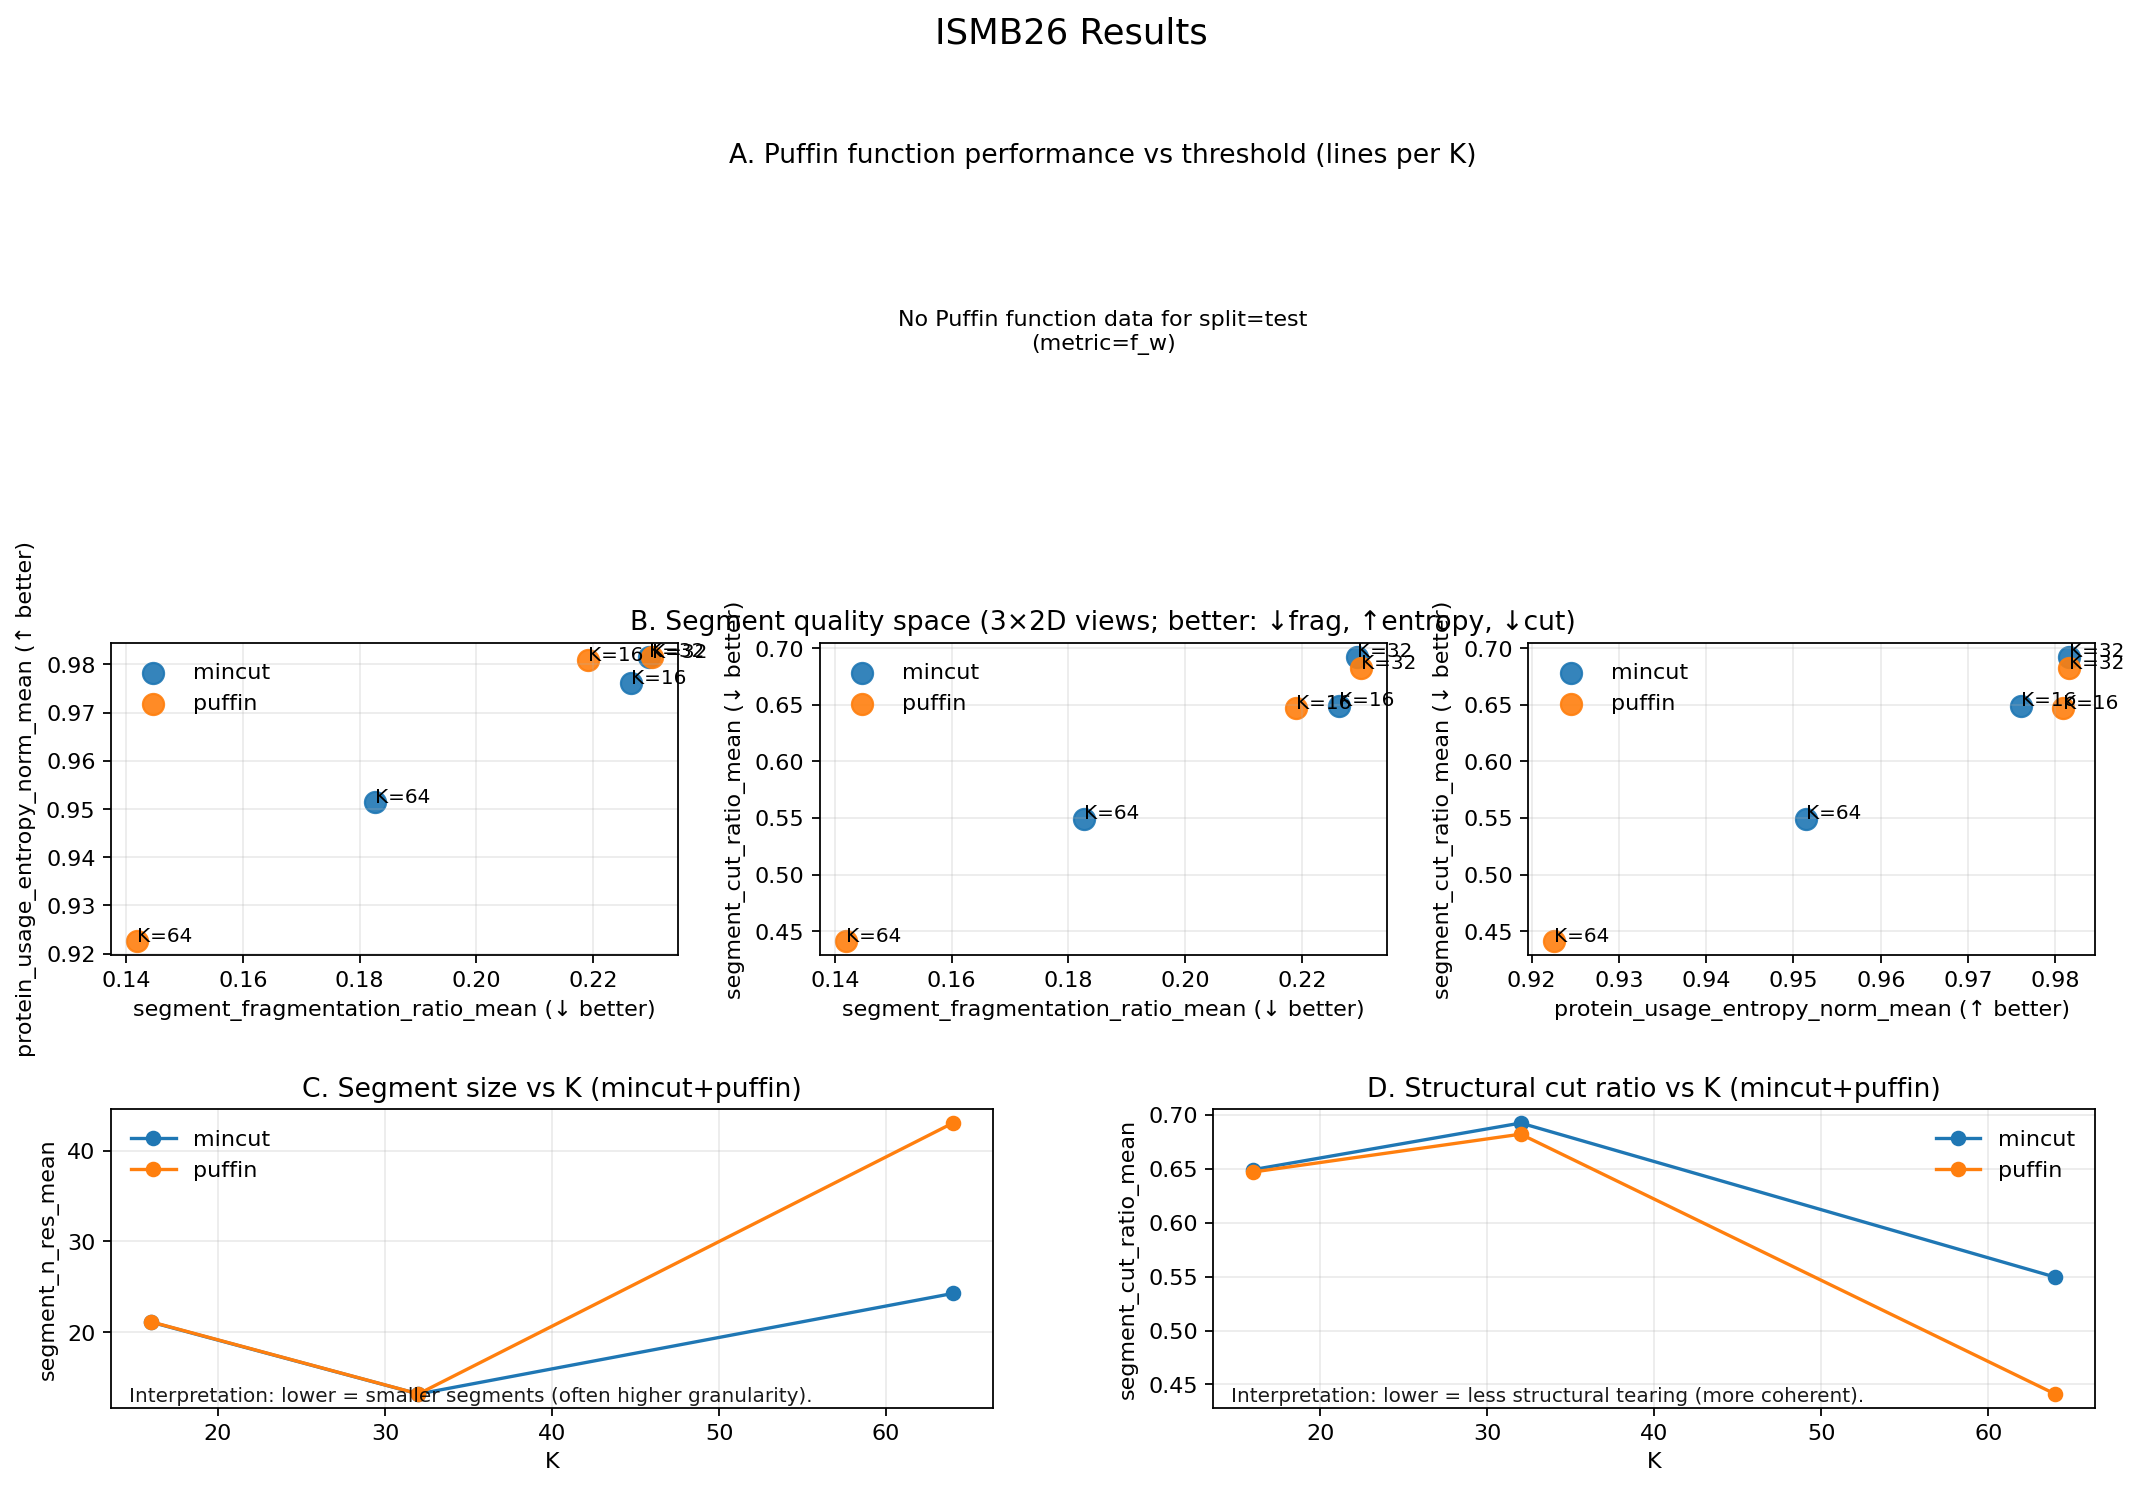

In [83]:
fig1 = plot_figure1(main_df, split="test", func_metric="f_w")
plt.show()



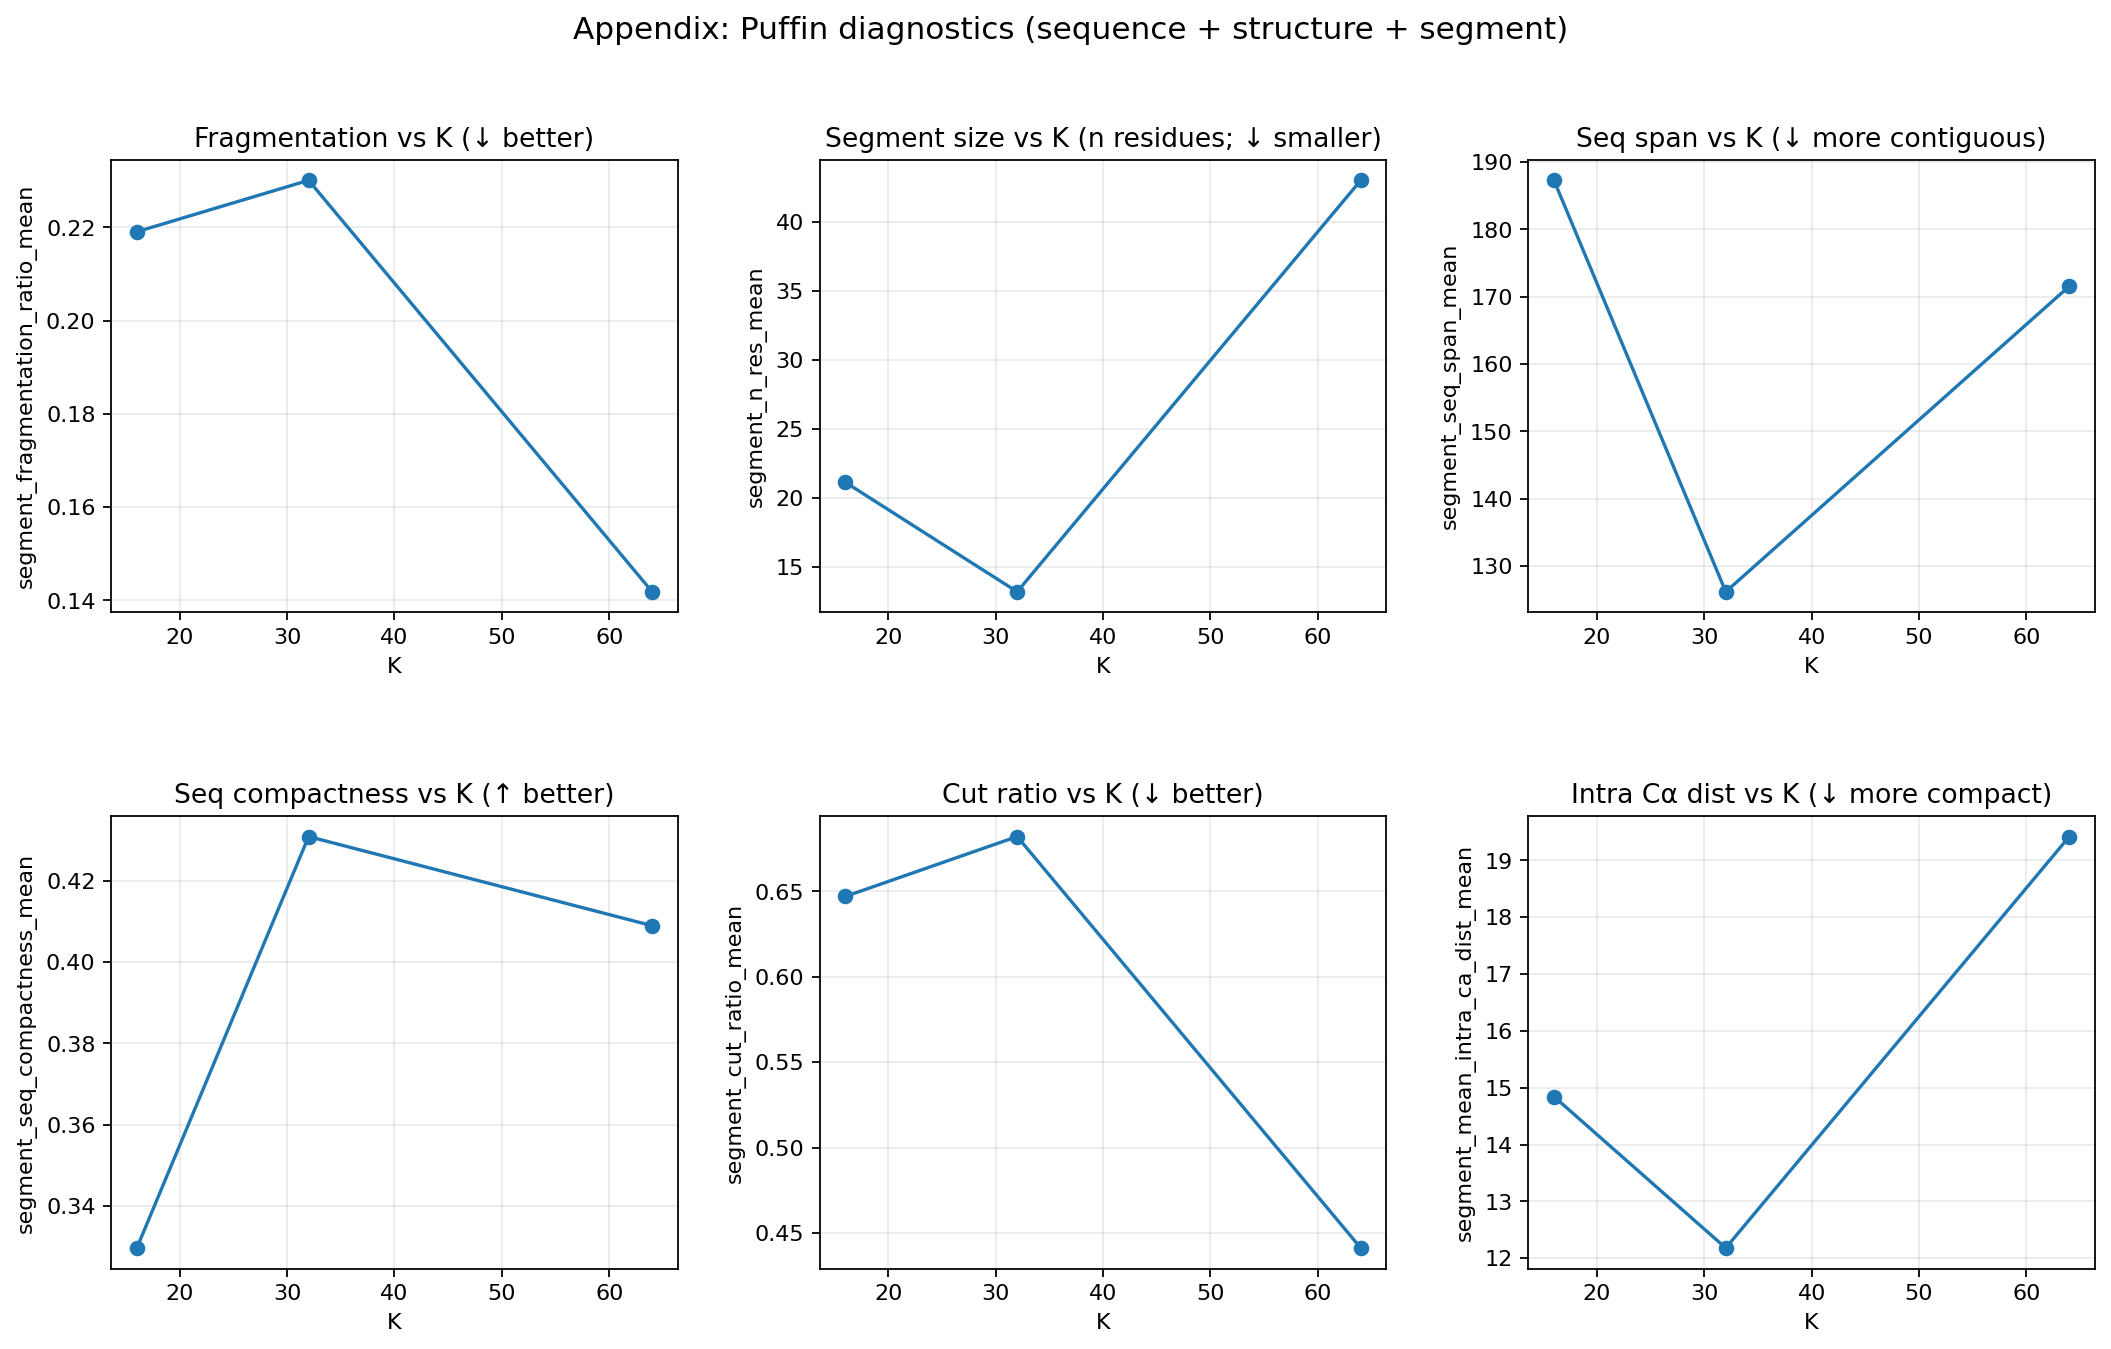

In [84]:
fig2 = plot_figure2_puffin_small_multiples(main_df, split="test")
plt.show()



# **Figure 1 — Main results**

## **A. Puffin function performance vs threshold**

**Observation**

* Function scores increase **monotonically with threshold** for all K.
* Ordering is **consistent across thresholds**:
  **K=64 > K=16 > K=32**.
* No instability or threshold-specific crossings.

**Interpretation**

* Puffin benefits from increased representational capacity.
* Threshold selection is **not brittle**: relative rankings are preserved.
* K=64 is the **best operating regime for downstream function prediction**.

**Key claim**

> *Puffin’s functional gains scale smoothly with K and are robust to threshold choice.*

---

## **B. Segment quality space (3×2D views: mincut + puffin)**

This is the **core diagnostic panel**.

### B1. Fragmentation vs usage entropy

* Puffin K=64 moves **strongly left** (↓ fragmentation) but **down** (↓ entropy).
* Mincut K=64 reduces entropy less but stays more fragmented.

**Interpretation**

* Puffin K=64 trades **unit diversity** for **segment contiguity**.
* This is *not collapse*: entropy remains high (>0.92).

---

### B2. Fragmentation vs structural cut ratio

* Puffin K=64 dominates mincut K=64:
  **lower fragmentation + lower cut ratio**.
* Mincut K=64 improves cut ratio modestly but remains fragmented.

**Interpretation**

* Puffin segments are both **more sequentially coherent** *and* **less structurally tearing**.

---

### B3. Usage entropy vs cut ratio

* Puffin K=64 is slightly worse in entropy but **best in cut ratio**.
* Mincut maintains higher entropy but higher structural tearing.

**Interpretation**

* Puffin sacrifices some diversity to gain **structural integrity**.

**Global interpretation of B**

> *Increasing K exposes different failure modes: mincut remains fragmented, while Puffin consolidates segments into fewer but more coherent units.*

---

## **C. Segment size vs K (mincut + puffin)**

**Observation**

* Both methods produce smallest segments at **K=32**.
* Puffin K=64 produces **much larger segments** than mincut K=64.

**Interpretation**

* Puffin uses high K to create **higher-level functional units**, not just more fragments.
* Mincut continues to split more aggressively as K grows.

**Important note**

* Larger segments are **not inherently degenerate** if fragmentation and cut ratio improve (they do — Panel B, D).

---

## **D. Structural cut ratio vs K (mincut + puffin)**

**Observation**

* Puffin K=64 achieves the **lowest cut ratio overall**.
* Mincut improves at K=64 but stays worse than Puffin.

**Interpretation**

* Puffin segments align better with **3D structural neighborhoods**.
* This strongly argues against Puffin’s K=64 solution being trivial or collapsed.

**Key claim**

> *Puffin K=64 minimizes structural tearing more effectively than mincut.*

---

# **Figure 2 — Appendix (Puffin-only diagnostics)**

This figure answers: *“Is Puffin K=64 degenerate?”*

### Fragmentation vs K

* Peaks at K=32, then **drops sharply at K=64**.

→ Segments become **cleaner**, not noisier.

---

### Segment size vs K

* K=64 → very large segments.

→ Expected when fragmentation decreases and semantic grouping strengthens.

---

### Sequence span vs K

* K=32 is most contiguous.
* K=64 spans increase, but fragmentation still drops.

→ Puffin learns **broader, possibly multi-domain functional units**, not random scattering.

---

### Sequence compactness vs K

* Sharp increase from K=16 → K=32.
* Slight drop at K=64, but still above K=16.

→ Best local contiguity at K=32; K=64 favors **global coherence** over strict locality.

---

### Cut ratio vs K

* Lowest at **K=64**.

→ Strongest evidence of **structure-aware segmentation**.

---

### Intra Cα distance vs K

* Lowest at K=32, highest at K=64.

→ Puffin allows larger structural extent at high K — consistent with larger units.

---

## **Unified interpretation of Figure 2**

> Puffin K=64 does not collapse into noise; rather, it transitions from fine-grained local segmentation (K=32) toward larger, structurally coherent functional units.

---

# **Final conclusions (copy-paste ready)**

> Increasing the number of segments K reveals qualitatively different behaviors between mincut and Puffin. While mincut continues to fragment proteins into smaller units, Puffin consolidates residues into fewer, larger, and more structurally coherent segments. At K=64, Puffin achieves the best downstream function prediction performance, the lowest segmentation fragmentation, and the lowest structural cut ratio, at the cost of reduced unit diversity and compactness. Importantly, extensive diagnostics rule out degenerate collapse: entropy remains high and both sequential and structural coherence improve. These results indicate that Puffin exploits increased capacity to discover higher-level, functionally meaningful protein units rather than over-segmenting the sequence.

---
